In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)
from ISLP import confusion_table
from ISLP.models import contrast

In [3]:
from sklearn.discriminant_analysis import (\
    LinearDiscriminantAnalysis as LDA,
    QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [4]:
import seaborn as sns

# Weekly Dataset

In [5]:
weekly = load_data("Weekly")
weekly

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up
...,...,...,...,...,...,...,...,...,...
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up


# (a)

In [6]:
weekly.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


<Axes: >

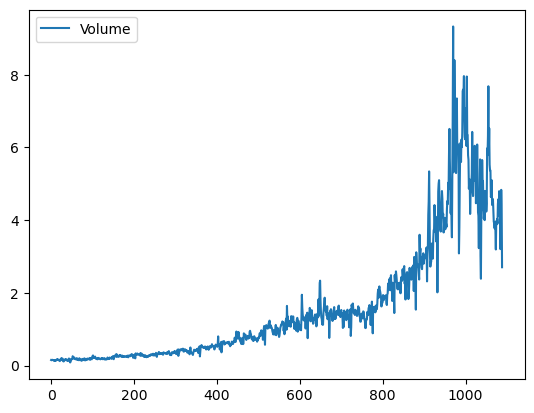

In [7]:
weekly.plot(y='Volume')

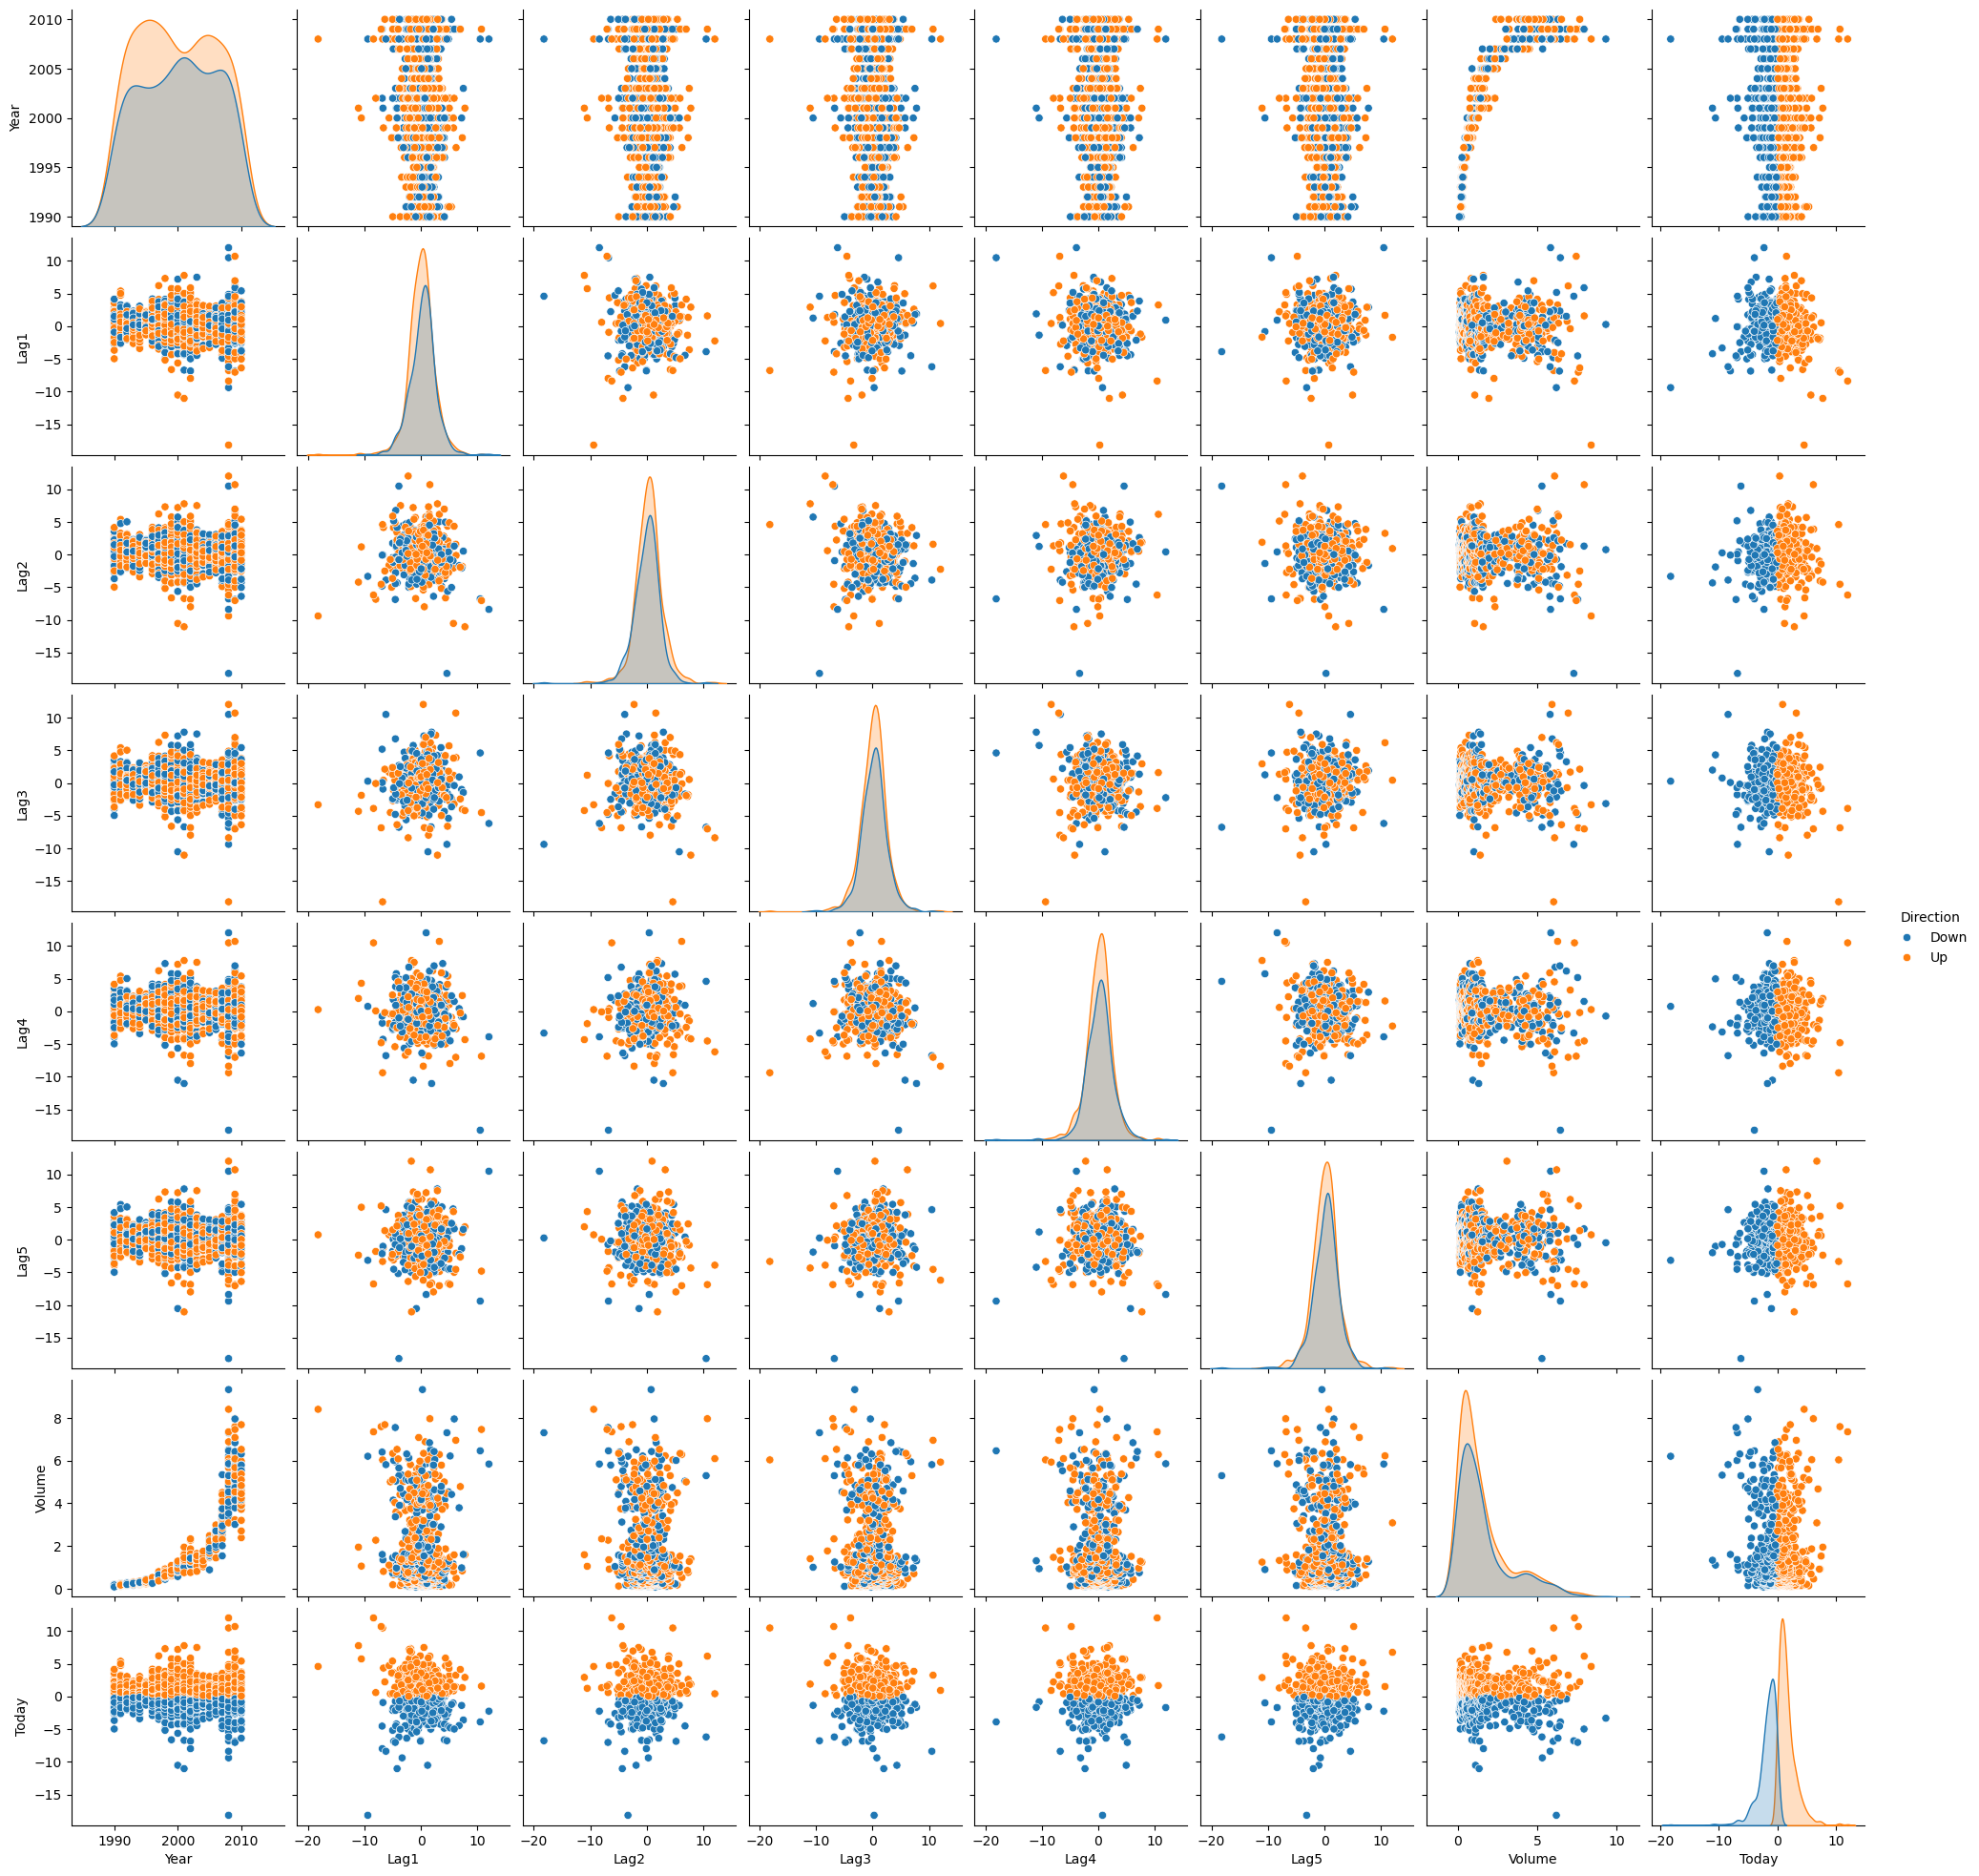

In [8]:
sns.pairplot(weekly, hue='Direction')

# (b)

In [9]:
allvars = weekly.columns
allvars

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

In [10]:
allvars = allvars.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(weekly)
y = weekly.Direction == 'Up'
glm = sm.GLM(y, X, family = sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


# (c)

In [11]:
probs = results.predict()
probs[0:10]

array([0.60862494, 0.60103144, 0.58756995, 0.48164156, 0.61690129,
       0.56841902, 0.57860971, 0.51519724, 0.57151998, 0.55542873])

In [12]:
labels = np.array(['Down']*1089)
labels[probs>0.5] = "Up"

In [13]:
confusion_table(labels, weekly.Direction)

Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [14]:
correct_prediction_rate = (54+557)/1089
correct_prediction_rate

0.5610651974288338

In [15]:
(54/(54+430), 557/(557+48))

(0.1115702479338843, 0.9206611570247933)

In [16]:
weekly["Direction"].value_counts()

Direction
Up      605
Down    484
Name: count, dtype: int64

In [17]:
605/(605+484)

0.5555555555555556

# (d)

In [18]:
train = (weekly.Year < 2009)
weekly_train = weekly.loc[train]["Lag2"]
weekly_test = weekly.loc[~train]["Lag2"]

In [19]:
train

0        True
1        True
2        True
3        True
4        True
        ...  
1084    False
1085    False
1086    False
1087    False
1088    False
Name: Year, Length: 1089, dtype: bool

In [20]:
design = MS(["Lag2"])
X = design.fit_transform(weekly)
y = weekly.Direction == 'Up'

In [21]:
X_train, X_test = X.loc[train], X.loc[~train]
y_train, y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train, X_train, family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

In [22]:
D = weekly.Direction
L_train, L_test = D.loc[train], D.loc[~train]

In [23]:
labels = np.array(['Down']*np.shape(y_test)[0])
labels[probs>0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [24]:
np.mean(labels == L_test)

np.float64(0.625)

In [25]:
np.mean(labels != L_test)

np.float64(0.375)

# (e)

In [26]:
lda = LDA(store_covariance=True)
X_train, X_test = [M.drop(columns=['intercept'])
                  for M in [X_train, X_test]]
lda.fit(X_train, L_train)

LinearDiscriminantAnalysis(store_covariance=True)

In [27]:
lda_pred = lda.predict(X_test)
confusion_table(lda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,9,5
Up,34,56


In [28]:
lda.classes_

array(['Down', 'Up'], dtype='<U4')

In [29]:
lda_prob = lda.predict_proba(X_test)
np.all(np.where(lda_prob[:,1] >= 0.5, 'Up', 'Down') == lda_pred)

np.True_

In [30]:
np.mean(lda_pred == L_test)

np.float64(0.625)

# (f)

In [31]:
qda = QDA(store_covariance=True)
qda.fit(X_train, L_train)

QuadraticDiscriminantAnalysis(store_covariance=True)

In [32]:
qda.classes_

array(['Down', 'Up'], dtype=object)

In [33]:
qda_pred = qda.predict(X_test)
confusion_table(qda_pred, L_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [34]:
qda_prob = qda.predict_proba(X_test)
np.all(np.where(qda_prob[:,1] >= 0.5, 'Up', 'Down') == qda_pred)

np.True_

In [35]:
(33+12)/(33+10+49+12)

0.4326923076923077

In [36]:
np.mean(qda_pred == L_test)

np.float64(0.5865384615384616)

# (g)

In [37]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, L_train)
knn1_pred = knn1.predict(X_test)
confusion_table(knn1_pred, L_test)

Truth,Down,Up
Predicted,,
Down,22,32
Up,21,29


In [38]:
np.mean(knn1_pred == L_test)

np.float64(0.49038461538461536)

# (h)

In [39]:
NB = GaussianNB()
NB.fit(X_train, L_train)

GaussianNB()

In [40]:
nb_labels =  NB.predict(X_test)
confusion_table(nb_labels, L_test)

Truth,Down,Up
Predicted,,
Down,0,0
Up,43,61


In [41]:
np.mean(nb_labels == L_test)

np.float64(0.5865384615384616)

# (i)

# (j)

## 1. Containing Lag2, Volume and Lag2*Volume terms.

In [42]:
X1 = MS(['Lag2', 'Volume', ('Lag2', 'Volume')]).fit_transform(weekly)
y1 = weekly.Direction == 'Up'
X1_train, X1_test = X1.loc[train], X1.loc[~train]
y1_train, y1_test = y1.loc[train], y1.loc[~train]

### Logistic Regression

In [43]:
glm_train1 = sm.GLM(y1_train, X1_train, family=sm.families.Binomial())
results1 = glm_train1.fit()
probs1 = results1.predict(exog=X1_test)
labels1 = np.array(['Down']*np.shape(y1_test)[0])
labels1[probs1>0.5] = 'Up'
confusion_table(labels1, L_test)

Truth,Down,Up
Predicted,,
Down,20,25
Up,23,36


In [59]:
summarize(results1)

,coef,std err,z,P>|z|
intercept,0.2701,0.090,2.993,0.003
Lag2,0.0504,0.040,1.260,0.208
Volume,-0.0544,0.053,-1.030,0.303
Lag2:Volume,0.0015,0.013,0.114,0.909


In [44]:
np.mean(labels1 == L_test)

np.float64(0.5384615384615384)

### LDA

In [45]:
lda_train1 = LDA(store_covariance=True)
lda_train1.fit(X1_train, L_train)
lda_pred1 = lda_train1.predict(X1_test)
confusion_table(lda_pred1, L_test)

Truth,Down,Up
Predicted,,
Down,20,25
Up,23,36


In [46]:
np.mean(lda_pred1 == L_test)

np.float64(0.5384615384615384)

### QDA

In [47]:
for reg_param in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    qda_train1 = QDA(store_covariance=True, reg_param=reg_param)
    qda_train1.fit(X1_train, L_train)
    qda_pred1 = qda_train1.predict(X1_test)
    print(confusion_table(qda_pred1, L_test))
    print(np.mean(qda_pred1 == L_test), '\n')

Truth      Down  Up
Predicted          
Down         43  61
Up            0   0
0.41346153846153844 

Truth      Down  Up
Predicted          
Down         36  47
Up            7  14
0.4807692307692308 

Truth      Down  Up
Predicted          
Down         36  47
Up            7  14
0.4807692307692308 

Truth      Down  Up
Predicted          
Down         36  46
Up            7  15
0.49038461538461536 

Truth      Down  Up
Predicted          
Down         36  46
Up            7  15
0.49038461538461536 

Truth      Down  Up
Predicted          
Down         36  46
Up            7  15
0.49038461538461536 



/home/sonu/miniconda3/envs/islp/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/sonu/miniconda3/envs/islp/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/sonu/miniconda3/envs/islp/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1052: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/home/sonu/miniconda3/envs/islp/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1052: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/home/sonu/miniconda3/envs/islp/lib/python3.13/site-packages/sklearn/discriminant_anal

### KNN

In [48]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X1_train, L_train)
knn1_pred1 = knn1.predict(X1_test)
confusion_table(knn1_pred1, L_test)

Truth,Down,Up
Predicted,,
Down,18,24
Up,25,37


In [49]:
np.mean(knn1_pred1 == L_test)

np.float64(0.5288461538461539)

In [65]:
for n_neighbor in range(1, 20):
    print(f'KNN for {n_neighbor} neighbors')
    knn = KNeighborsClassifier(n_neighbors=n_neighbor)
    knn.fit(X1_train, L_train)
    knn_pred = knn.predict(X1_test)
    print(confusion_table(knn_pred, L_test))
    print('Mean:', np.mean(knn_pred == L_test), '\n')

KNN for 1 neighbors
Truth      Down  Up
Predicted          
Down         17  24
Up           26  37
Mean: 0.5192307692307693 

KNN for 2 neighbors
Truth      Down  Up
Predicted          
Down         28  42
Up           15  19
Mean: 0.4519230769230769 

KNN for 3 neighbors
Truth      Down  Up
Predicted          
Down          8  22
Up           35  39
Mean: 0.4519230769230769 

KNN for 4 neighbors
Truth      Down  Up
Predicted          
Down         19  32
Up           24  29
Mean: 0.46153846153846156 

KNN for 5 neighbors
Truth      Down  Up
Predicted          
Down         12  25
Up           31  36
Mean: 0.46153846153846156 

KNN for 6 neighbors
Truth      Down  Up
Predicted          
Down         21  33
Up           22  28
Mean: 0.47115384615384615 

KNN for 7 neighbors
Truth      Down  Up
Predicted          
Down          9  24
Up           34  37
Mean: 0.4423076923076923 

KNN for 8 neighbors
Truth      Down  Up
Predicted          
Down         14  29
Up           29  32
Mean: 0.

### Naive Bayes

In [50]:
NB1 = GaussianNB()
NB.fit(X1_train, L_train)
nb_labels1 =  NB.predict(X1_test)
confusion_table(nb_labels1, L_test)

Truth,Down,Up
Predicted,,
Down,42,57
Up,1,4


In [51]:
np.mean(nb_labels1 == L_test)

np.float64(0.4423076923076923)

## 2 Containing Lag2, Lag2^2, Volume, Volume^2 and Lag2*Volume terms. (Not implemented yet)

In [60]:
X2 = MS([poly('Lag2', degree=2), poly('Volume', degree=2), ('Lag2', 'Volume')]).fit_transform(weekly)
y2 = weekly.Direction == 'Up'
X2_train, X2_test = X2.loc[train], X2.loc[~train]
y2_train, y2_test = y2.loc[train], y2.loc[~train]